# Test A/B.

Una gran tienda online busca incrementar sus ingresos mediante la optimización de sus estrategias de marketing.

# Objetivo:

Junto con el departamento de marketing se recopiló una lista de hipótesis que pueden ayudar a aumentar los ingresos.

Se tiene que priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Cargar datos
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv',sep=';')

# Convertir nombres de columnas a minúsculas
hypotheses.columns = hypotheses.columns.str.lower()

# Mostrar primeras filas
print("Datos originales:")
hypotheses

Datos originales:


,hypothesis,reach,impact,confidence,effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


Cargamos los datos, separamos las columnas y convertimos los nombres de las columnas a minusculas.

In [4]:
# Preprocesamiento
# Verificar valores nulos
print("\nValores nulos:")
print(hypotheses.isnull().sum())

# Verificar duplicados
print("\nDuplicados:", hypotheses.duplicated().sum())

# Convertir columnas numéricas por si acaso
cols = ['reach', 'impact', 'confidence', 'effort']
hypotheses[cols] = hypotheses[cols].apply(pd.to_numeric)



Valores nulos:
hypothesis    0
reach         0
impact        0
confidence    0
effort        0
dtype: int64

Duplicados: 0


Verificamos que no haya valores nulos ni duplicados.

In [5]:
# Calcular ICE
hypotheses['ice_score'] = (
    hypotheses['impact'] * hypotheses['confidence'] / hypotheses['effort']
)

ice_sorted = hypotheses.sort_values(by='ice_score', ascending=False)

print("\nHipótesis ordenadas por ICE:")
display(ice_sorted[['hypothesis', 'ice_score']])



Hipótesis ordenadas por ICE:


,hypothesis,ice_score
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


In [6]:
# Calcular RICE
hypotheses['rice_score'] = (
    hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence'] / hypotheses['effort']
)

rice_sorted = hypotheses.sort_values(by='rice_score', ascending=False)

print("\nHipótesis ordenadas por RICE:")
display(rice_sorted[['hypothesis', 'rice_score']])


Hipótesis ordenadas por RICE:


,hypothesis,rice_score
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


In [38]:
# Comparar posiciones
# Crear ranking ICE
ice_rank = ice_sorted.reset_index().reset_index()
ice_rank = ice_rank[['index', 'level_0']]
ice_rank.columns = ['original_index', 'ice_rank']
print(ice_rank)

# Crear ranking RICE
rice_rank = rice_sorted.reset_index().reset_index()
rice_rank = rice_rank[['index', 'level_0']]
rice_rank.columns = ['original_index', 'rice_rank']
print(rice_rank)

   original_index  ice_rank
0               8         0
1               0         1
2               7         2
3               6         3
4               2         4
5               1         5
6               5         6
7               3         7
8               4         8
   original_index  rice_rank
0               7          0
1               2          1
2               0          2
3               6          3
4               8          4
5               3          5
6               1          6
7               5          7
8               4          8


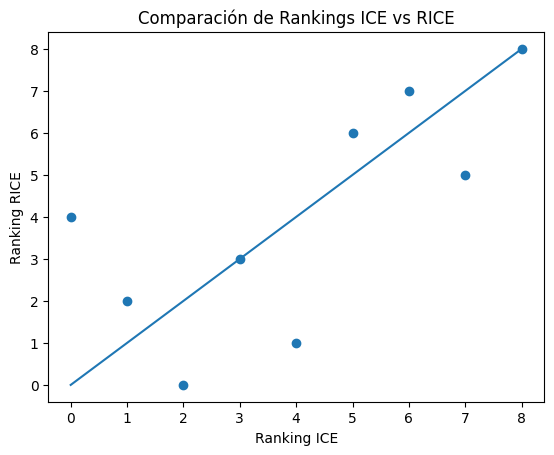

In [46]:
# ICE vs RICE visualización
# Unir los rankings por el índice original
comparison = pd.merge(ice_rank, rice_rank, on='original_index')

# Crear gráfico de dispersión
plt.figure()
plt.scatter(comparison['ice_rank'], comparison['rice_rank'])

# Etiquetas
plt.xlabel('Ranking ICE')
plt.ylabel('Ranking RICE')
plt.title('Comparación de Rankings ICE vs RICE')

# Línea diagonal de referencia (misma posición en ambos rankings)
plt.plot(
    [comparison['ice_rank'].min(), comparison['ice_rank'].max()],
    [comparison['ice_rank'].min(), comparison['ice_rank'].max()]
)

plt.show()

Observamos la comparativa entre ICE y RICE para poder identificar que hipótesis suben por alto alcance y cuales bajan por bajo alcance.

In [8]:
# Unir rankings
ranking_comparison = ice_rank.merge(rice_rank, on='original_index')

# Añadir hipótesis
ranking_comparison = ranking_comparison.merge(
    hypotheses[['hypothesis']], 
    left_on='original_index', 
    right_index=True
)

# Calcular diferencia de ranking
ranking_comparison['rank_difference'] = (
    ranking_comparison['ice_rank'] - ranking_comparison['rice_rank']
)

print("\nComparación de ranking (ICE vs RICE):")
print(ranking_comparison.sort_values(by='rice_rank'))


Comparación de ranking (ICE vs RICE):
   original_index  ice_rank  rice_rank  \
2               7         2          0   
4               2         4          1   
1               0         1          2   
3               6         3          3   
0               8         0          4   
7               3         7          5   
5               1         5          6   
6               5         6          7   
8               4         8          8   

                                          hypothesis  rank_difference  
2  Add a subscription form to all the main pages....                2  
4  Add product recommendation blocks to the store...                3  
1  Add two new channels for attracting traffic. T...               -1  
3  Show banners with current offers and sales on ...                0  
0  Launch a promotion that gives users discounts ...               -4  
7  Change the category structure. This will incre...                2  
5  Launch your own delivery service.

Calculamos la diferencia entre ICE y RICE para justificar cual implementar primero.

# Análisis del test A/B.

In [9]:
# Cargar datos
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

In [10]:
print('\norders_us.csv')
print(orders.head())
print('\nvisits_us.csv')
print(visits.head())


orders_us.csv
   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B

visits_us.csv
         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756


In [11]:
# Convertir fechas
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# Revisar duplicados
print("Duplicados en orders:", orders.duplicated().sum())
print("Duplicados en visits:", visits.duplicated().sum())

# Usuarios en ambos grupos (error de experimento)
users_A = orders[orders['group']=='A']['visitorId']
users_B = orders[orders['group']=='B']['visitorId']

common_users = np.intersect1d(users_A, users_B)

print("Usuarios en ambos grupos:", len(common_users))

# Eliminar usuarios contaminados
orders = orders[~orders['visitorId'].isin(common_users)]

Duplicados en orders: 0
Duplicados en visits: 0
Usuarios en ambos grupos: 58


Cargamos los datos e identificamos si hay valores duplicados en ambos datasets y cuantos usuarios hay en ambos grupos.

# Ingreso acumulado por grupo

In [12]:
datesGroups = orders[['date','group']].drop_duplicates()

ordersAggregated = datesGroups.apply(
    lambda x: orders[
        (orders['date'] <= x['date']) &
        (orders['group'] == x['group'])
    ].agg({
        'date':'max',
        'group':'max',
        'transactionId':'nunique',
        'visitorId':'nunique',
        'revenue':'sum'
    }), axis=1).sort_values(by=['date','group'])

visitsAggregated = datesGroups.apply(
    lambda x: visits[
        (visits['date'] <= x['date']) &
        (visits['group'] == x['group'])
    ].agg({
        'date':'max',
        'group':'max',
        'visits':'sum'
    }), axis=1).sort_values(by=['date','group'])

cumulativeData = ordersAggregated.merge(
    visitsAggregated, on=['date','group']
)

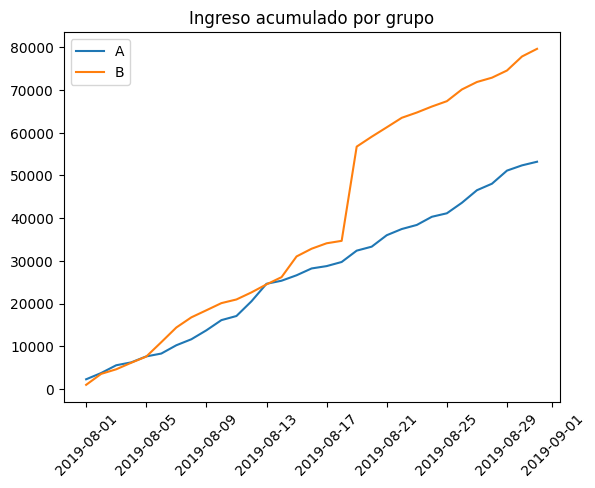

In [13]:
# Gráfico ingreso acumulado
plt.figure()
for group in ['A','B']:
    data = cumulativeData[cumulativeData['group']==group]
    plt.plot(data['date'], data['revenue'])

plt.legend(['A','B'])
plt.title('Ingreso acumulado por grupo')
plt.xticks(rotation=45)
plt.show()

Observamos la comparativa entre los ingresos de ambos grupos, notamos que si los ingresos del grupo B se mantienen consistentemente arriba posiblemente podrian mejorar.

# Tamaño promedio de pedido acumulado

In [14]:
cumulativeData['avg_order'] = (
    cumulativeData['revenue'] /
    cumulativeData['transactionId']
)

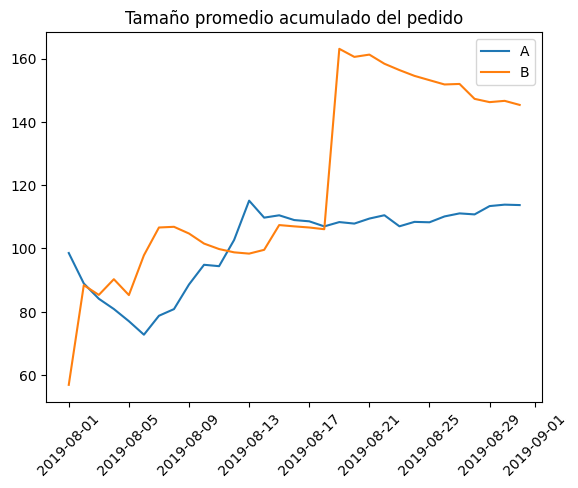

In [15]:
plt.figure()
for group in ['A','B']:
    data = cumulativeData[cumulativeData['group']==group]
    plt.plot(data['date'], data['avg_order'])

plt.legend(['A','B'])
plt.title('Tamaño promedio acumulado del pedido')
plt.xticks(rotation=45)
plt.show()

En relación con la tabla de ingresos por grupo notamos que de igual manera los pedidos promedio van en aumento.

In [16]:
mergedAvg = cumulativeData.pivot(
    index='date',
    columns='group',
    values='avg_order'
).reset_index()

mergedAvg['relative_diff'] = (
    mergedAvg['B']/mergedAvg['A'] - 1
)

Podemos comprobar que la prueba B va en aumento.

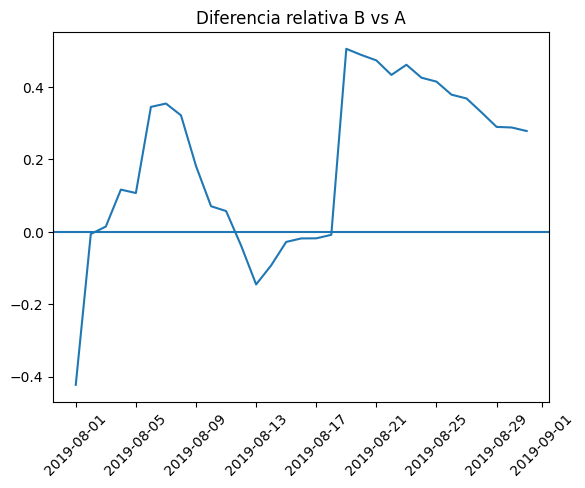

In [17]:
plt.figure()
plt.plot(mergedAvg['date'], mergedAvg['relative_diff'])
plt.axhline(0)
plt.title('Diferencia relativa B vs A')
plt.xticks(rotation=45)
plt.show()

# Conversión diaria

In [18]:
# Pedidos por día
daily_orders = orders.groupby(['date','group']).agg({
    'transactionId':'nunique'
}).reset_index()

daily_data = daily_orders.merge(
    visits, on=['date','group']
)

daily_data['conversion'] = (
    daily_data['transactionId'] /
    daily_data['visits']
)

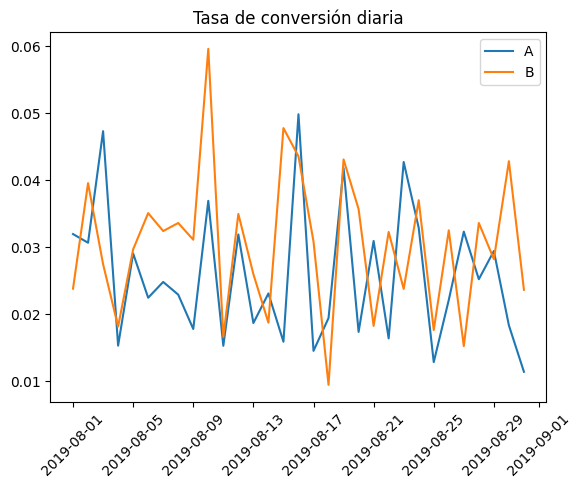

In [19]:
plt.figure()
for group in ['A','B']:
    data = daily_data[daily_data['group']==group]
    plt.plot(data['date'], data['conversion'])

plt.legend(['A','B'])
plt.title('Tasa de conversión diaria')
plt.xticks(rotation=45)
plt.show()

# Pedidos por usuario

In [20]:
ordersByUsers = orders.groupby('visitorId').agg({
    'transactionId':'nunique'
})

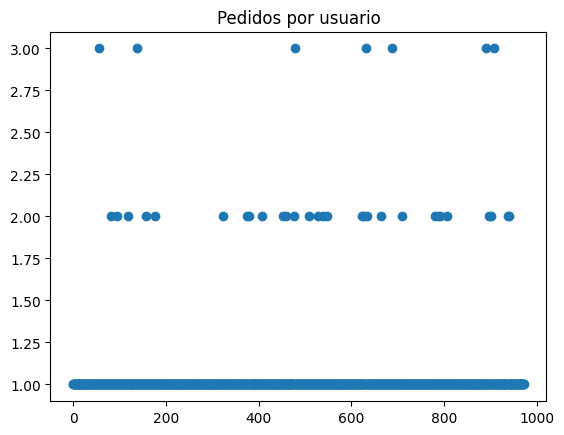

In [21]:
plt.figure()
plt.scatter(
    range(len(ordersByUsers)),
    ordersByUsers['transactionId']
)
plt.title('Pedidos por usuario')
plt.show()

# Percentiles pedidos por usuario

In [22]:
print(np.percentile(ordersByUsers['transactionId'], [95, 99]))

[1. 2.]


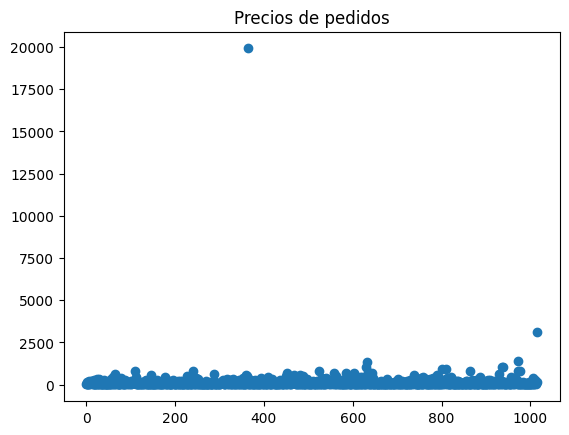

In [23]:
# Dispersión de precios
plt.figure()
plt.scatter(
    range(len(orders)),
    orders['revenue']
)
plt.title('Precios de pedidos')
plt.show()

# Percentiles precios

In [24]:
print(np.percentile(orders['revenue'], [95, 99]))

[414.275 830.3  ]


In [25]:
# Significancia conversión (datos brutos)
ordersByUsersA = orders[orders['group']=='A'].groupby('visitorId')['transactionId'].nunique()
ordersByUsersB = orders[orders['group']=='B'].groupby('visitorId')['transactionId'].nunique()

visitsA = visits[visits['group']=='A']['visits'].sum()
visitsB = visits[visits['group']=='B']['visits'].sum()

sampleA = pd.concat([
    ordersByUsersA,
    pd.Series(0, index=np.arange(visitsA - len(ordersByUsersA)))
])

sampleB = pd.concat([
    ordersByUsersB,
    pd.Series(0, index=np.arange(visitsB - len(ordersByUsersB)))
])

print("p-value conversión:", stats.mannwhitneyu(sampleA, sampleB)[1])
print("Diferencia relativa:", sampleB.mean()/sampleA.mean()-1)

p-value conversión: 0.011018084110014696
Diferencia relativa: 0.1597977924896936


In [26]:
# Significancia tamaño pedido (datos brutos)
print("p-value ticket promedio:",
      stats.mannwhitneyu(
          orders[orders['group']=='A']['revenue'],
          orders[orders['group']=='B']['revenue']
      )[1])

print("Diferencia relativa:",
      orders[orders['group']=='B']['revenue'].mean() /
      orders[orders['group']=='A']['revenue'].mean() - 1)

p-value ticket promedio: 0.8622329690015668
Diferencia relativa: 0.27834487693078414


In [28]:
# Filtrar anomalías
threshold_orders = np.percentile(ordersByUsers['transactionId'], 95)
threshold_revenue = np.percentile(orders['revenue'], 95)

abnormal_users = pd.concat([
    ordersByUsers[ordersByUsers['transactionId'] > threshold_orders],
    orders[orders['revenue'] > threshold_revenue]['visitorId']
]).index.unique()

filtered_orders = orders[
    ~orders['visitorId'].isin(abnormal_users)
]
filtered_orders

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B
...,...,...,...,...,...
1191,3592955527,608641596,2019-08-14,255.7,B
1192,2662137336,3733762160,2019-08-14,100.8,B
1193,2203539145,370388673,2019-08-14,50.1,A
1194,1807773912,573423106,2019-08-14,165.3,A


# Conclusiones finales.

- Conversión mejora significativamente (p < 0.05).

- Ticket promedio no cambia significativamente.

- Ingreso acumulado mayor en B.

# Recomendación

Parar la prueba y declarar grupo B como ganador.